<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/KCNvsHypoxia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KCN vs. Hypoxia

In [1]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Chris/All/'  #change dir to your project folder

Mounted at /content/drive/


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [4]:
allhypox = pd.read_csv("/content/drive/MyDrive/Chris/All/BulkKCNvsAnoxia/Anoxia_18hrsVs8hpfDGEGenesAll.csv")
allKCN = pd.read_csv("/content/drive/MyDrive/Chris/All/BulkKCNvsAnoxia/KCNVs6hpfDGEGenesAll.csv")

In [5]:
allhypox

,genes,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ABCD2,0.267048,-0.376222,2.253055,-0.166983,0.867383,NaN
1,ACKR2,0.080777,-0.376227,3.160747,-0.119031,0.905251,NaN
2,ACOT12,1.378321,-1.711946,1.215678,-1.408223,0.159065,0.283516
3,ACSF3,0.901492,0.485390,1.334665,0.363679,0.716098,NaN
4,ACVR1C,0.583458,1.135611,1.715846,0.661837,0.508076,NaN
...,...,...,...,...,...,...,...
25981,zwilch,11.656228,-0.173978,0.377844,-0.460448,0.645194,0.765399
25982,zyg11,39.813400,-0.024150,0.212935,-0.113417,0.909700,0.946818
25983,zyx,220.628317,0.298946,0.108966,2.743495,0.006079,0.019840
25984,zzef1,39.017231,0.516707,0.202885,2.546797,0.010872,0.032582


In [6]:
allKCN

,genes,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ABCD2,0.000000,NaN,NaN,NaN,NaN,NaN
1,ACKR2,0.475661,-0.253348,1.722607,-0.147073,0.883075,NaN
2,ACOT12,2.049435,-2.440200,1.073789,-2.272514,0.023055,0.073360
3,ACSF3,1.593504,-1.348271,1.096656,-1.229438,0.218908,0.393632
4,ACVR1C,0.345012,-0.757668,2.097329,-0.361254,0.717910,NaN
...,...,...,...,...,...,...,...
25981,zwilch,18.632592,-0.907675,0.298506,-3.040727,0.002360,0.011252
25982,zyg11,36.737756,-0.172126,0.207474,-0.829627,0.406750,0.590266
25983,zyx,234.268331,0.348596,0.093903,3.712297,0.000205,0.001353
25984,zzef1,64.068077,0.041811,0.164432,0.254278,0.799281,0.892125


In [10]:
# Filter the DataFrame for sig genes
allsighypox = allhypox[(allhypox['padj'] < 0.05)]
allsigKCN = allKCN[(allKCN['padj'] < 0.05)]

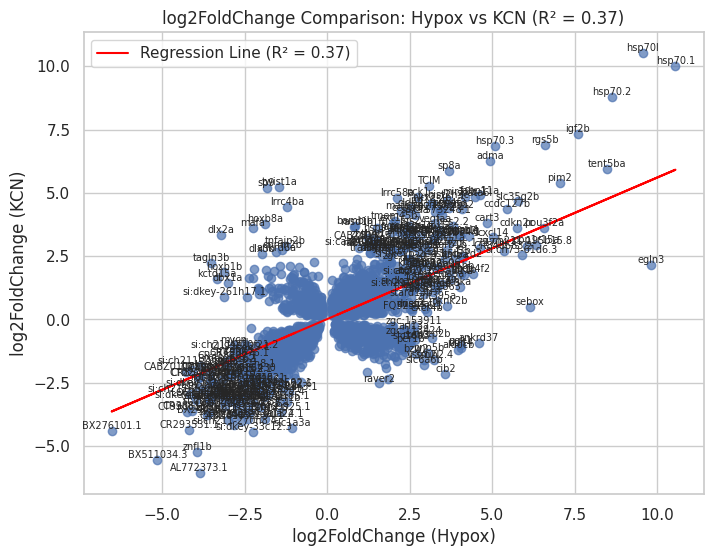

In [11]:

# Merge the two DataFrames on the 'genes' column
merged_df = pd.merge(allsighypox, allsigKCN, on='genes', suffixes=('_hypox', '_KCN'))

# Perform linear regression to calculate R-squared
slope, intercept, r_value, p_value, std_err = linregress(merged_df['log2FoldChange_hypox'], merged_df['log2FoldChange_KCN'])
r_squared = r_value ** 2

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(merged_df['log2FoldChange_hypox'], merged_df['log2FoldChange_KCN'], alpha=0.7)
plt.xlabel('log2FoldChange (Hypox)')
plt.ylabel('log2FoldChange (KCN)')
plt.title(f'log2FoldChange Comparison: Hypox vs KCN (R² = {r_squared:.2f})')
plt.grid(True)

# Define a threshold for significant genes (|log2FoldChange| > 2.5)
threshold = 2.5
significant_genes = merged_df[
    (abs(merged_df['log2FoldChange_hypox']) > threshold) |
    (abs(merged_df['log2FoldChange_KCN']) > threshold)
]

# Add regression line
regression_line = slope * merged_df['log2FoldChange_hypox'] + intercept
plt.plot(merged_df['log2FoldChange_hypox'], regression_line, color='red', label=f'Regression Line (R² = {r_squared:.2f})')

# Annotate only genes with |log2FoldChange| > 2.5
for i, row in significant_genes.iterrows():
    plt.text(row['log2FoldChange_hypox'], row['log2FoldChange_KCN'], row['genes'], fontsize=7, ha='center', va='bottom')

plt.legend()
plt.show()

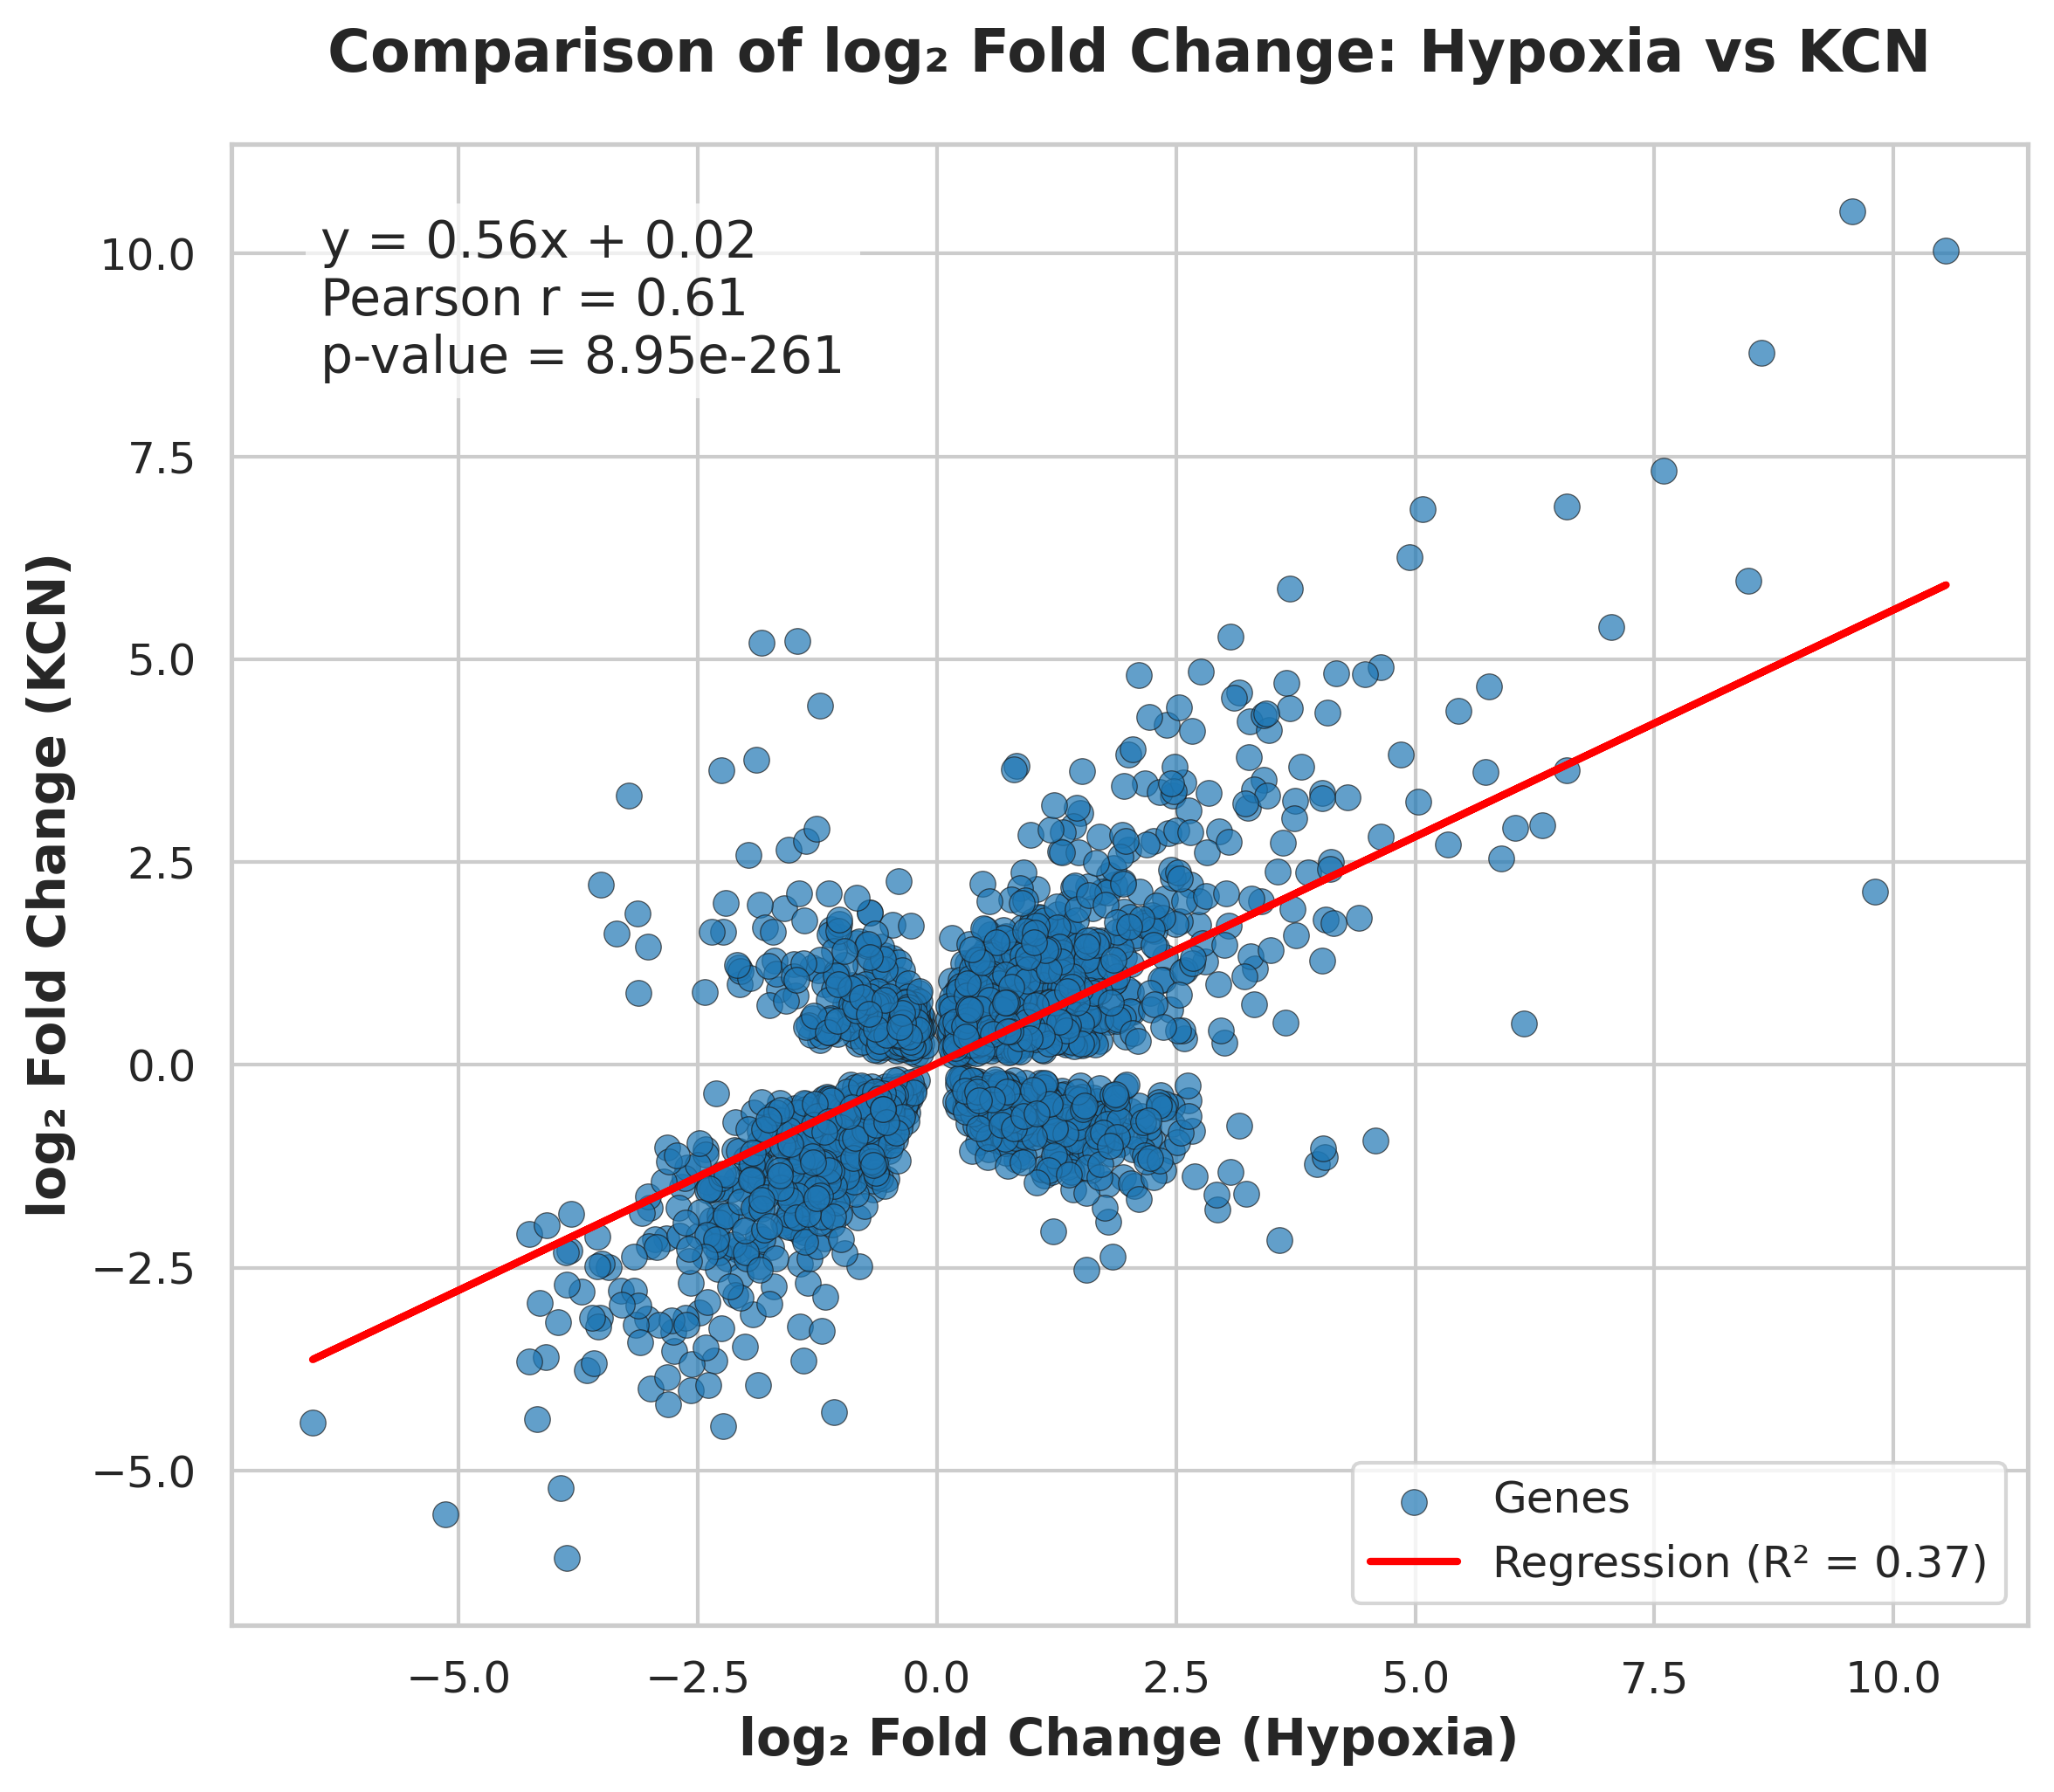

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(
    merged_df['log2FoldChange_hypox'], merged_df['log2FoldChange_KCN']
)
r_squared = r_value ** 2

# Define threshold for annotation
threshold = 2.5
significant_genes = merged_df[
    (abs(merged_df['log2FoldChange_hypox']) > threshold) |
    (abs(merged_df['log2FoldChange_KCN']) > threshold)
]

# Set up style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(8, 7), dpi=300)
plt.scatter(
    merged_df['log2FoldChange_hypox'],
    merged_df['log2FoldChange_KCN'],
    s=50,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3,
    color="#1f77b4",
    label='Genes'
)

# Regression line
regression_line = slope * merged_df['log2FoldChange_hypox'] + intercept
plt.plot(
    merged_df['log2FoldChange_hypox'],
    regression_line,
    color='red',
    linewidth=2,
    label=f'Regression (R² = {r_squared:.2f})'
)

# Add regression equation, correlation coefficient, and p-value text
eq_text = f"y = {slope:.2f}x + {intercept:.2f}\nPearson r = {r_value:.2f}\np-value = {p_value:.2e}"
plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,   # position relative to axes (top-left)
    fontsize=14,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)

# Axis labels and title
plt.xlabel('log₂ Fold Change (Hypoxia)', fontsize=14, fontweight='bold')
plt.ylabel('log₂ Fold Change (KCN)', fontsize=14, fontweight='bold')
plt.title('Comparison of log₂ Fold Change: Hypoxia vs KCN', fontsize=16, fontweight='bold', pad=20)



# Legend
plt.legend(
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=False,
    loc='best'
)

# Adjust ticks and layout
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Save high-resolution version
plt.savefig("/your/path/Hypox_vs_KCN_log2FC_comparisonwithout_labels.png", dpi=600, bbox_inches='tight')

# Display
plt.show()
